In [1]:
import sys
import warnings
import numpy as np
import networkx as nx
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# RDKit
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D

# Visualisation
from IPython.display import display, Image as IPImage
from PIL import Image
import io

# Pipeline modules (adjust path if needed)
# sys.path.insert(0, "/path/to/your/project")
from graph_encoders.wl import WL
from dict_learners.aksvd import AKSVD
from utils.graph_data import GraphDataLoader
from interpreter.wl_aksvd_interpreter import WLAKSVDInterpreter

warnings.filterwarnings("ignore")

In [2]:
from collections import Counter

data_loader = GraphDataLoader()
graphs, y = data_loader.nci_full_graphs, data_loader.nci_full_labels

print(f"Dataset size : {len(graphs)} graphs")
print(f"Label dist.  : {Counter(y)}")
print()

# Inspect first graph
sample_g = graphs[0]

print(f"Sample graph : {sample_g.number_of_nodes()} nodes, {sample_g.number_of_edges()} edges")

# First few nodes
print("\nFirst 5 nodes:")
for node_id, attrs in list(sample_g.nodes(data=True))[:5]:
    print(f"  Node {node_id}: {attrs}")

# First few edges
print("\nFirst 3 edges:")
for u, v, attrs in list(sample_g.edges(data=True))[:3]:
    print(f"  {u} -- {v}: {attrs}")

# Determine the attribute key and value type
sample_node = list(sample_g.nodes(data=True))[0]

print("\nSample node")
print(f"Node ID   : {sample_node[0]}")
print(f"Attributes: {sample_node[1]}")
print(f"Attr keys : {list(sample_node[1].keys())}")

Loading NCI dataset


[23:23:45] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] ERROR: Could not sanitize molecule ending on line 5976
[23:23:45] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] Explicit valence for atom # 0 Br, 1, is greater than permitted
[23:23:45] ERROR: Could not sanitize molecule ending on line 9488
[23:23:45] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[23:23:45] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] ERROR: Could not sanitize molecule ending on line 12926
[23:23:45] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] ERROR: Could not sanitize molecule ending on line 13981
[23:23:45] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:23:45] ERROR: Could not sanitize mol

Loaded 36937 graphs
Dataset size : 36937 graphs
Label dist.  : Counter({-1: 35203, 1: 1734})

Sample graph : 44 nodes, 47 edges

First 5 nodes:
  Node 0: {'feature': 'Cl'}
  Node 1: {'feature': 'O'}
  Node 2: {'feature': 'O'}
  Node 3: {'feature': 'O'}
  Node 4: {'feature': 'O'}

First 3 edges:
  0 -- 29: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}
  1 -- 12: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}
  1 -- 13: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}

Sample node
Node ID   : 0
Attributes: {'feature': 'Cl'}
Attr keys : ['feature']


In [3]:
print(type(graphs))
print(len(graphs))

<class 'list'>
36937


SMILES --> NetworkX Graph Converter

In [4]:
# ──────────────────────────────────────────────────────────────────────────
# Configuration — adjust these if your NCI graphs use a different format
# ──────────────────────────────────────────────────────────────────────────
ATTR_KEY = "feature"          # node attribute key read by WeisfeilerLehmanHashing


def _atom_feature(atom) -> str:
    """
    Convert an RDKit atom to the same string representation used in the NCI
    training graphs.

    Default: atomic number as a plain string ("6" for carbon, "7" for nitrogen).
    Change this function if your NCI graphs use element symbols, one-hot
    vectors, or a different encoding.
    """
    return str(atom.GetAtomicNum())


def smiles_to_graph(smiles: str) -> nx.Graph:
    """
    Parse a SMILES string and return a NetworkX graph compatible with the
    WL-AKSVD pipeline.

    Node attributes match the NCI training format so that WL hashing
    produces tokens from the same vocabulary.

    Parameters
    ----------
    smiles : str
        A valid SMILES string (e.g. "c1ccccc1" for benzene).

    Returns
    -------
    nx.Graph
        Undirected graph with consecutive integer node IDs (0-indexed)
        and the expected node attribute.

    Raises
    ------
    ValueError
        If RDKit cannot parse the SMILES string.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: '{smiles}'")

    # Add explicit hydrogens if the NCI graphs include them
    # (uncomment the next line if your NCI data includes H atoms)
    # mol = Chem.AddHs(mol)

    g = nx.Graph()

    for atom in mol.GetAtoms():
        g.add_node(atom.GetIdx(), **{ATTR_KEY: _atom_feature(atom)})

    for bond in mol.GetBonds():
        g.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    return g


def smiles_to_mol_and_graph(smiles: str):
    """Return both the RDKit Mol and the pipeline-ready NetworkX graph."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: '{smiles}'")
    graph = smiles_to_graph(smiles)
    return mol, graph

In [5]:
graphs[0]

In [6]:
# Convert benzene and compare attribute format with NCI
test_g = smiles_to_graph("c1ccccc1")
nci_sample = graphs[0]

print("SMILES graph (benzene):")
print(f"  Nodes: {dict(list(test_g.nodes(data=True))[:3])}")
print()
print("NCI sample graph:")
print(f"  Nodes: {dict(list(nci_sample.nodes(data=True))[:3])}")
print()

smiles_attrs = set(list(test_g.nodes(data=True))[0][1].keys())
nci_attrs   = set(list(nci_sample.nodes(data=True))[0][1].keys())
if smiles_attrs == nci_attrs:
    print("✅ Attribute keys match — converter is compatible.")
else:
    print(f"⚠️  Mismatch: SMILES uses {smiles_attrs}, NCI uses {nci_attrs}")
    print("   Update ATTR_KEY and _atom_feature() to match.")

SMILES graph (benzene):
  Nodes: {0: {'feature': '6'}, 1: {'feature': '6'}, 2: {'feature': '6'}}

NCI sample graph:
  Nodes: {0: {'feature': 'Cl'}, 1: {'feature': 'O'}, 2: {'feature': 'O'}}

✅ Attribute keys match — converter is compatible.


In [7]:
# ── Data splits ───────────────────────────────────────────────────────────
G_train, G_test, y_train, y_test = train_test_split(
    graphs, y, test_size=0.2, random_state=42
)
G_vocab_train, G_ML_train, y_vocab_train, y_ML_train = train_test_split(
    G_train, y_train, test_size=0.75, random_state=42
)

print(f"Vocab train : {len(G_vocab_train)}")
print(f"ML train    : {len(G_ML_train)}")
print(f"Test        : {len(G_test)}")

# ── WL hashing ────────────────────────────────────────────────────────────
wl = WL()
wl_embeddings_vocab = wl.generate_training_embeddings(G_vocab_train, y_vocab_train)
print(f"Vocab size  : {wl.n_vocab}")

# ── AKSVD dictionary learning ────────────────────────────────────────────
aksvd = AKSVD()
aksvd.fit(training_graph_embeddings=wl_embeddings_vocab)
print(f"Dictionary  : {aksvd._dictionary.shape}")

# ── Generate sparse codes for ML train & test ─────────────────────────────
wl_emb_ml_train = wl.generate_inferencing_embeddings(G_ML_train)
X_ML_train = aksvd.infer(wl_emb_ml_train)

wl_emb_test = wl.generate_inferencing_embeddings(G_test)
X_ML_test = aksvd.infer(wl_emb_test)

# ── Scaling ───────────────────────────────────────────────────────────────
scaler = MaxAbsScaler()
X_ML_train_scaled = scaler.fit_transform(X_ML_train)
X_ML_test_scaled = scaler.transform(X_ML_test)

Vocab train : 7387
ML train    : 22162
Test        : 7388
Selected 6690 features via adaptive selection
Vocab size  : 6690
Dictionary  : (128, 6690)


In [8]:
# Logistic Regression is preferred for interpretability because coef_
# gives per-atom signed attribution (unlike tree-based feature_importances_)
classifier = LogisticRegression(
    max_iter=1000,
    solver="saga",
    random_state=42,
    class_weight="balanced",
)
classifier.fit(X_ML_train_scaled, y_ML_train)

y_pred = classifier.predict(X_ML_test_scaled)
print(classification_report(y_test, y_pred))
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

          -1       0.98      0.81      0.89      7027
           1       0.15      0.65      0.24       361

    accuracy                           0.80      7388
   macro avg       0.56      0.73      0.56      7388
weighted avg       0.94      0.80      0.85      7388

Test accuracy: 0.8005


In [9]:
LABEL_MAP = {0: "Non-Cancerous", 1: "Cancerous"}

interpreter = WLAKSVDInterpreter(
    wl=wl,
    aksvd=aksvd,
    classifier=classifier,
    scaler=scaler,
    training_graphs=G_ML_train,
    training_labels=y_ML_train,
    training_sparse_codes=X_ML_train,   # unscaled, for cosine similarity
    label_map=LABEL_MAP,
)

print("✅ Interpreter ready.")

✅ Interpreter ready.


In [10]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def _importance_colour_map(
    node_importance: dict,
    sorted_nodes: list,
    supporting_cmap: str = "Reds",
    opposing_cmap: str = "Blues",
    floor_alpha: float = 0.15,
) -> dict:
    """
    Map each node to an RGBA tuple based on signed importance.

    Supporting nodes  → red gradient   (pushes toward predicted class)
    Opposing nodes    → blue gradient  (pushes against predicted class)

    Nodes with zero importance get a faint wash so they remain visible.
    """
    if not sorted_nodes:
        return {}

    max_abs = max(abs(s) for _, s in sorted_nodes) or 1.0
    sup_cm = cm.get_cmap(supporting_cmap)
    opp_cm = cm.get_cmap(opposing_cmap)

    colours = {}
    for node_id, score in sorted_nodes:
        intensity = abs(score) / max_abs
        # Scale into [floor_alpha, 1.0] so even low-importance atoms are visible
        mapped = floor_alpha + intensity * (1.0 - floor_alpha)

        if score >= 0:
            rgba = sup_cm(mapped)
        else:
            rgba = opp_cm(mapped)

        colours[node_id] = rgba

    return colours


def visualise_prediction(
    smiles: str,
    interpreter: "WLAKSVDInterpreter",
    top_k_atoms: int = 5,
    img_size: tuple = (600, 400),
    show_atom_indices: bool = True,
    show_percentages: bool = True,
    supporting_cmap: str = "Reds",
    opposing_cmap: str = "Blues",
) -> Image.Image:
    """
    End-to-end: SMILES → classification → node-importance → highlighted image.

    Parameters
    ----------
    smiles           : SMILES string to classify and explain.
    interpreter      : fitted WLAKSVDInterpreter.
    top_k_atoms      : number of dictionary atoms to trace.
    img_size         : (width, height) of the output image.
    show_atom_indices: annotate atoms with their index.
    show_percentages : annotate atoms with importance %.
    supporting_cmap  : matplotlib colourmap name for supporting atoms.
    opposing_cmap    : matplotlib colourmap name for opposing atoms.

    Returns
    -------
    PIL.Image.Image  — the rendered molecule with highlighting.
    """
    mol, graph = smiles_to_mol_and_graph(smiles)

    # Run interpretability
    result = interpreter.get_node_importance(graph, top_k_atoms=top_k_atoms)

    # Compute 2D coordinates for a clean layout
    AllChem.Compute2DCoords(mol)

    # Build colour map
    sorted_nodes = result["sorted_nodes"]
    colour_map = _importance_colour_map(
        result["node_importance"],
        sorted_nodes,
        supporting_cmap=supporting_cmap,
        opposing_cmap=opposing_cmap,
    )

    # Prepare RDKit highlight arguments
    highlight_atoms = list(colour_map.keys())
    highlight_atom_colours = {
        int(k): tuple(v[:3]) for k, v in colour_map.items()
    }

    # Highlight bonds connecting two highlighted atoms
    highlight_bonds = []
    highlight_bond_colours = {}
    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if a1 in colour_map and a2 in colour_map:
            bid = bond.GetIdx()
            highlight_bonds.append(bid)
            # Average the colours of the two endpoint atoms
            c1 = np.array(colour_map[a1][:3])
            c2 = np.array(colour_map[a2][:3])
            highlight_bond_colours[bid] = tuple((c1 + c2) / 2)

    # Draw with the SVG renderer for crisp output
    drawer = rdMolDraw2D.MolDraw2DCairo(*img_size)
    opts = drawer.drawOptions()
    opts.useBWAtomPalette()

    if show_atom_indices:
        for atom in mol.GetAtoms():
            idx = atom.GetIdx()
            if show_percentages and idx in result["node_importance_pct"]:
                pct = result["node_importance_pct"][idx]
                atom.SetProp("atomNote", f"{pct:.1f}%")
            else:
                atom.SetProp("atomNote", str(idx))

    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_atom_colours,
        highlightBonds=highlight_bonds,
        highlightBondColors=highlight_bond_colours,
    )
    drawer.FinishDrawing()

    bio = io.BytesIO(drawer.GetDrawingText())
    return Image.open(bio)


def full_analysis(
    smiles: str,
    interpreter: "WLAKSVDInterpreter",
    top_k_atoms: int = 5,
    img_size: tuple = (700, 450),
):
    """
    Full end-to-end analysis: classification, text report, and visualisation.
    """
    mol, graph = smiles_to_mol_and_graph(smiles)

    # 1. Full text report
    report = interpreter.full_report(
        graph,
        top_k_atoms=top_k_atoms,
        top_k_features_per_atom=5,
        top_k_similar=5,
    )
    print(report)

    # 2. Highlighted visualisation
    img = visualise_prediction(
        smiles,
        interpreter,
        top_k_atoms=top_k_atoms,
        img_size=img_size,
    )
    display(img)

    return img

═════════════════════════════════════════════════════════════════
  PREDICTION   : -1
  CONFIDENCE   : 82.5%
  ACTIVE ATOMS : 0
═════════════════════════════════════════════════════════════════
  CONTRIBUTION BREAKDOWN          [S = Supporting | O = Opposing]
  Dictionary Atom            Bar                                   %
─────────────────────────────────────────────────────────────────
  Others                     ██████████████████████████████  100.0%
═════════════════════════════════════════════════════════════════

── LEVEL 1: Prediction Reasoning ─────────────────────────────────────────
  Prediction : -1  (Confidence: 82.5%)
  Atoms driving this prediction:

── LEVEL 2: Dictionary Atom Composition ───────────────────────────────────

── LEVEL 4: Similar Training Compounds ────────────────────────────────────
  #1  idx=22161  label=-1                similarity=0.0%
  #2  idx=22160  label=-1                similarity=0.0%
  #3  idx=22159  label=-1                similarity=0.0

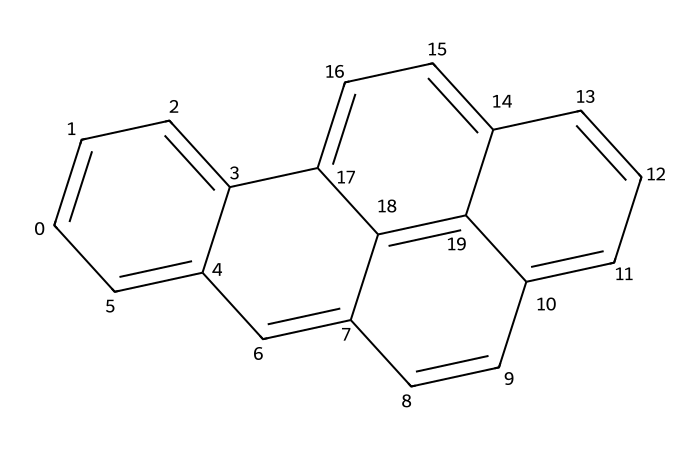

In [11]:
# ──────────────────────────────────────────────────────────────────────────
# ⬇️  CHANGE THIS SMILES STRING TO CLASSIFY ANY MOLECULE  ⬇️
# ──────────────────────────────────────────────────────────────────────────
SMILES = "c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34"   # Pyrene

img = full_analysis(SMILES, interpreter, top_k_atoms=5)

──────────────────────────────────────────────────
  Benzene (c1ccccc1)
  → -1  (conf: 82.5%)
  Active dictionary atoms: 0


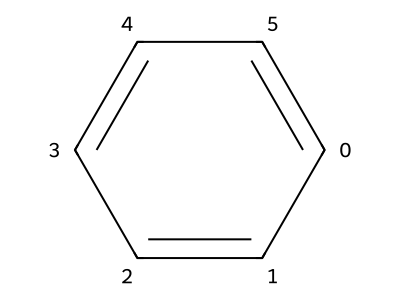

──────────────────────────────────────────────────
  Naphthalene (c1ccc2ccccc2c1)
  → -1  (conf: 82.5%)
  Active dictionary atoms: 0


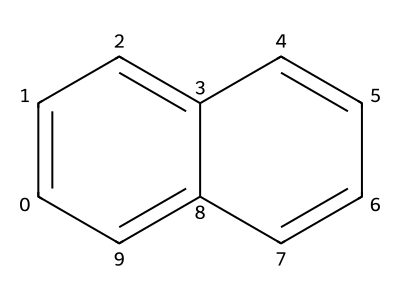

──────────────────────────────────────────────────
  Phenol (Oc1ccccc1)
  → -1  (conf: 82.5%)
  Active dictionary atoms: 0


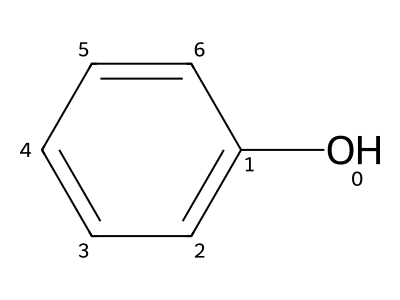

──────────────────────────────────────────────────
  Aniline (Nc1ccccc1)
  → -1  (conf: 82.5%)
  Active dictionary atoms: 0


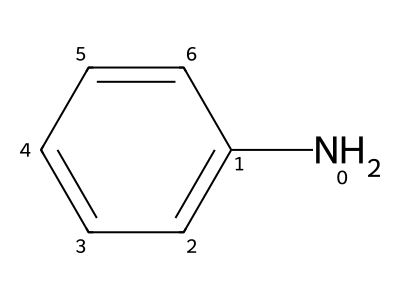

──────────────────────────────────────────────────
  Cyclohexane (C1CCCCC1)
  → -1  (conf: 82.5%)
  Active dictionary atoms: 0


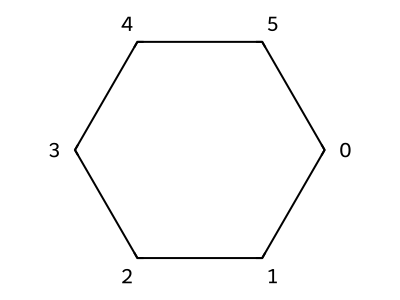

──────────────────────────────────────────────────
  Aspirin (CC(=O)Oc1ccccc1C(=O)O)
  → -1  (conf: 82.5%)
  Active dictionary atoms: 0


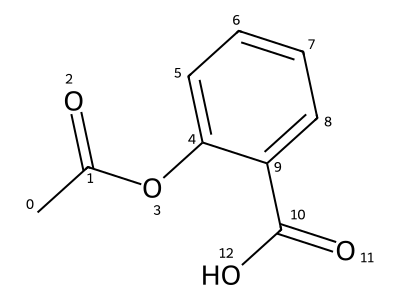


──────────────────────────────────────────────────
Summary:
  Benzene          → -1                conf=82.5%
  Naphthalene      → -1                conf=82.5%
  Phenol           → -1                conf=82.5%
  Aniline          → -1                conf=82.5%
  Cyclohexane      → -1                conf=82.5%
  Aspirin          → -1                conf=82.5%


In [12]:
COMPOUNDS = {
    "Benzene":          "c1ccccc1",
    "Naphthalene":      "c1ccc2ccccc2c1",
    "Phenol":           "Oc1ccccc1",
    "Aniline":          "Nc1ccccc1",
    "Cyclohexane":      "C1CCCCC1",
    "Aspirin":          "CC(=O)Oc1ccccc1C(=O)O",
}

results_summary = []

for name, smi in COMPOUNDS.items():
    mol, graph = smiles_to_mol_and_graph(smi)
    explanation = interpreter.explain_prediction(graph, top_k_atoms=5)

    results_summary.append({
        "Compound": name,
        "SMILES": smi,
        "Prediction": explanation["prediction_label"],
        "Confidence": (
            f"{explanation['confidence']*100:.1f}%"
            if explanation["confidence"] is not None else "N/A"
        ),
        "Active Atoms": explanation["n_active_atoms"],
    })

    print(f"{'─'*50}")
    print(f"  {name} ({smi})")
    print(f"  → {explanation['prediction_label']}"
          f"  (conf: {explanation['confidence']*100:.1f}%)"
          if explanation['confidence'] else "")
    print(f"  Active dictionary atoms: {explanation['n_active_atoms']}")

    img = visualise_prediction(smi, interpreter, top_k_atoms=5, img_size=(400, 300))
    display(img)

print(f"\n{'─'*50}")
print("Summary:")
for r in results_summary:
    print(f"  {r['Compound']:<16} → {r['Prediction']:<16}  conf={r['Confidence']}")